In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
from xgboost import XGBClassifier

import warnings

warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
df = pd.read_csv("/content/insurance_claims.csv")


# **1. Categorical vs Categorical (Binary Classification)**

**The Chi-Square ($\chi^2$) Test is a statistical "detective" tool used to determine if there is a significant connection between two categorical variables. In your case, it helps you decide which features (like gender, accident type, or severity) are actually useful for predicting Fraud.**

Decoding Your Metrics:

When we look at our results table,  we should keep these two rules of thumb in mind:T
- The p-value (The "Luck" Factor): This tells us the probability that the relationship we see is just a coincidence.

  - p < 0.05 This is the "Gold Standard." It means there is less than a 5% chance this is a coincidence. We Reject the Null Hypothesis ($H_0$), meaning the feature is a "Winner" and should stay in your model.
  - p > 0.05: This means the connection is weak or non-existent. We Fail to Reject $H_0$, meaning the feature is "Noise" and should be dropped.

**Chi-Squared Test**


**Null Hypothesis:** The two categorical variables have no relationship (independent)

**Alternate Hypothesis:** There is a relationship between two categorical variables (dependannt)

      - H0 : (Feature not important)
      - H1 : (Feature important)

Null Hypothesis is trying to tell the probability of observing data at least as extreme as the ones we've observed is assuming the all categories in features did in reality have the same frequency of fraud.

In [ ]:
from scipy.stats import  chi2_contingency
list_cat_col = []

for col in df.columns:
    if (df[col].dtype =='object'):
        list_cat_col.append(col)



x_cat = df[list_cat_col].loc[: , ~df[list_cat_col].columns.isin(["fraud_reported"])]
y_cat = df['fraud_reported']

alpha = 0.05

p_values_ = dict()
for col in x_cat.columns:

    chi2_data = pd.crosstab(x_cat[col], y_cat)

    chi2, p, dof, expected = chi2_contingency(chi2_data)

    p_values_.setdefault('column', []).append(col)
    p_values_.setdefault('p_values', []).append(p)
    p_values_.setdefault('chi2', []).append(chi2)

    if p < alpha:
        p_values_.setdefault('result', []).append('Reject Ho')

    else:
        p_values_.setdefault('result', []).append('Failed to Reject Ho')

chi2_data = pd.DataFrame(p_values_).set_index('column')
chi2_data

,p_values,chi2,result
column,,,
policy_bind_date,3.226353e-01,969.532576,Failed to Reject Ho
policy_state,5.996317e-01,1.022879,Failed to Reject Ho
policy_csl,3.435237e-01,2.136999,Failed to Reject Ho
insured_sex,3.666514e-01,0.814982,Failed to Reject Ho
insured_education_level,9.460265e-01,1.688227,Failed to Reject Ho
insured_occupation,1.708876e-01,17.659340,Failed to Reject Ho
insured_hobbies,8.989147e-25,162.315399,Reject Ho
insured_relationship,3.702431e-01,5.389248,Failed to Reject Ho
incident_date,3.449221e-01,62.747756,Failed to Reject Ho


**The High-Impact Features (Reject $H_0$)**

These are the columns that have a real, statistical impact on whether a claim is fraud:

- incident_severity: By far the most important. Major accidents are much more likely to be linked to specific fraud patterns.
- insured_hobbies: Surprisingly significant. This suggests that certain lifestyle choices or behaviors correlate with insurance risk in this dataset.
- incident_type & collision_type: How the accident happened provides a strong signal.
- incident_state & authorities_contacted: Regional patterns and the involvement of police/fire departments matter.


**The Low-Impact Features (Fail to Reject $H_0$)**

These columns are "distractions" for your model. They don't help in predicting
 - fraud:insured_sex & insured_education_level: Gender and degree level have no statistical link to fraud here.
 - policy_state: It doesn't matter which state the policy was signed in.- incident_city: The specific city doesn't provide a reliable pattern.

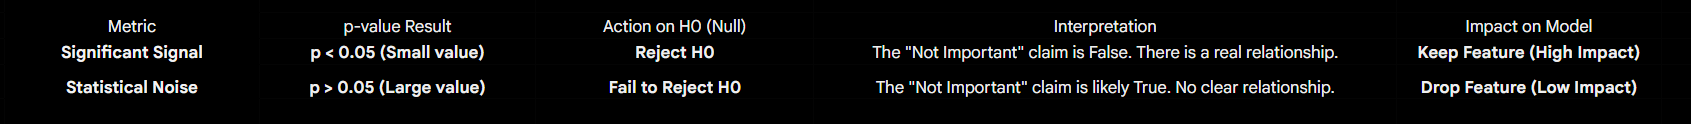

In [ ]:
chi_score_feature = chi2_data[chi2_data['result']=='Reject Ho'].index.to_list()
chi_score_feature

['policy_bind_date',
 'policy_csl',
 'insured_sex',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_location',
 'property_damage',
 'auto_make',
 'auto_model']

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

chi2_data_2 = df.copy()

for col in x_cat.columns:

    chi2_data_2[col] = label_encoder.fit_transform(chi2_data_2[col])

chi2_data_2.fraud_reported = label_encoder.fit_transform(chi2_data_2.fraud_reported)

chi_score = chi2(chi2_data_2[x_cat.columns], chi2_data_2.fraud_reported)

p_values_ = pd.Series(chi_score[1], index = chi2_data_2[x_cat.columns].columns)

In [ ]:
p_values_[p_values_ < 0.05]

,0
insured_hobbies,7.086420e-03
incident_date,3.388471e-07
collision_type,4.121145e-03
incident_severity,1.539047e-28
authorities_contacted,3.726509e-04
incident_location,3.094072e-04



# **2. Numeric vs Categoric (Binary Classification)**

In [ ]:

from statsmodels.formula.api import ols
from scipy.stats import shapiro

shapiro_ = {}

for i,col in enumerate(list_num_col):
    model = ols(f'Q("{col}") ~ fraud_reported',
            data=pd.concat([df[list_num_col], df['fraud_reported']], axis=1)
           ).fit()

    shapiro_.setdefault('column', []).append(col)
    shapiro_.setdefault('shapiro', []).append(shapiro(model.resid)[1])

    if shapiro(model.resid)[1] < 0.01:
        shapiro_.setdefault('result', []).append('Reject Ho')
    else:
        shapiro_.setdefault('result', []).append('Failed to Reject Ho')

shapiro_ = pd.DataFrame(shapiro_).set_index('column')

In [ ]:
shapiro_

,shapiro,result
column,,
months_as_customer,5.865675e-12,Reject Ho
age,6.660939e-12,Reject Ho
policy_number,8.749797e-16,Reject Ho
policy_deductable,4.983701e-35,Reject Ho
umbrella_limit,5.106448e-44,Reject Ho
insured_zip,2.114322e-37,Reject Ho
capital-gains,4.735771e-33,Reject Ho
capital-loss,9.922029e-32,Reject Ho
incident_hour_of_the_day,1.287615e-17,Reject Ho


**Normality Test: Probability Plot**

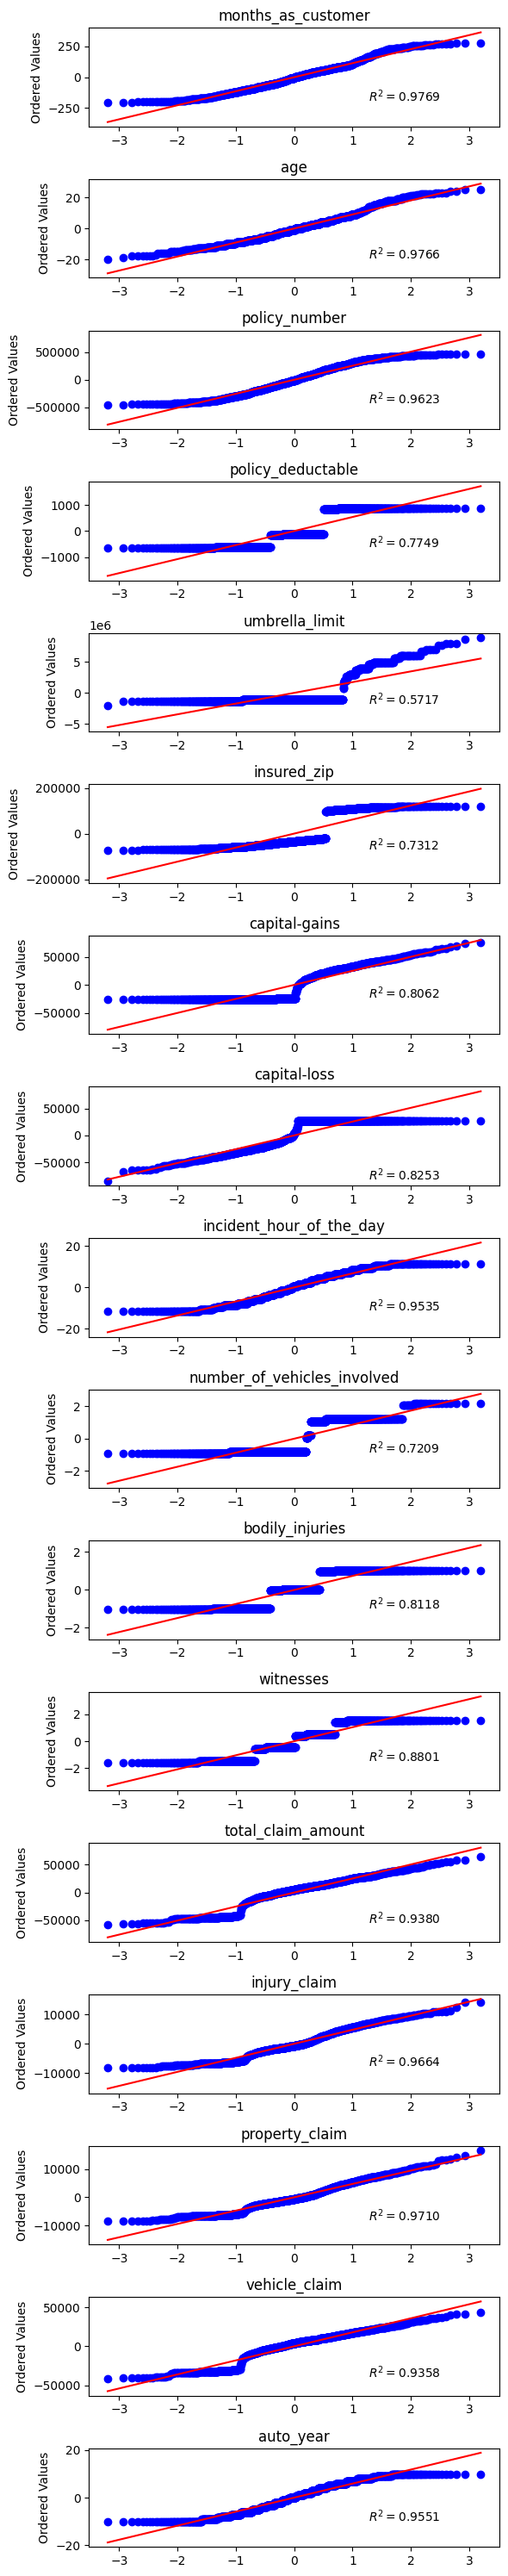

In [ ]:
from scipy.stats import probplot

fig, axes = plt.subplots(17, 1, figsize=(6,30))

for i, col in enumerate(list_num_col):

    model = ols(f'Q("{col}") ~ fraud_reported',
            data=pd.concat([df[list_num_col], df['fraud_reported']], axis=1)
           ).fit()


    normality_plot, stat = probplot(model.resid, plot = axes[i], rvalue = True)

    axes[i].set_title(col)
    axes[i].set_xlabel('')


fig.tight_layout()
plt.show()

**Equal Variance Test: Levene Test**

- Null Hypothesis: Equal Variances
- Alternative Hypothesis: Inequal Variances

In [ ]:

from scipy.stats import levene


list_num_col = []

for col in df.columns:
    if (df[col].dtype =='int'):
        list_num_col.append(col)


levene_test = dict()

for col in list_num_col:

    levene_ = levene(
                        df[col][df['fraud_reported']=='Y'],
                        df[col][df['fraud_reported']=='N']
                    )

    levene_test.setdefault('column',[]).append(col)
    levene_test.setdefault('levene',[]).append(levene_[1])

    if levene_[1] < 0.01:
        levene_test.setdefault('result', []).append('Reject Ho')

    else:
        levene_test.setdefault('result', []).append('Failed to Reject Ho')

levene_test = pd.DataFrame(levene_test).set_index('column').reset_index()
levene_test

,column,levene,result
0,months_as_customer,2.664079e-01,Failed to Reject Ho
1,age,1.520673e-01,Failed to Reject Ho
2,policy_number,6.729104e-01,Failed to Reject Ho
3,policy_deductable,2.444860e-01,Failed to Reject Ho
4,umbrella_limit,6.605811e-02,Failed to Reject Ho
5,insured_zip,7.442249e-01,Failed to Reject Ho
6,capital-gains,5.447871e-01,Failed to Reject Ho
7,capital-loss,4.388683e-01,Failed to Reject Ho
8,incident_hour_of_the_day,6.150990e-01,Failed to Reject Ho
9,number_of_vehicles_involved,1.013520e-01,Failed to Reject Ho


# **3. Numeric vs Numeric (Multicollinearity)**

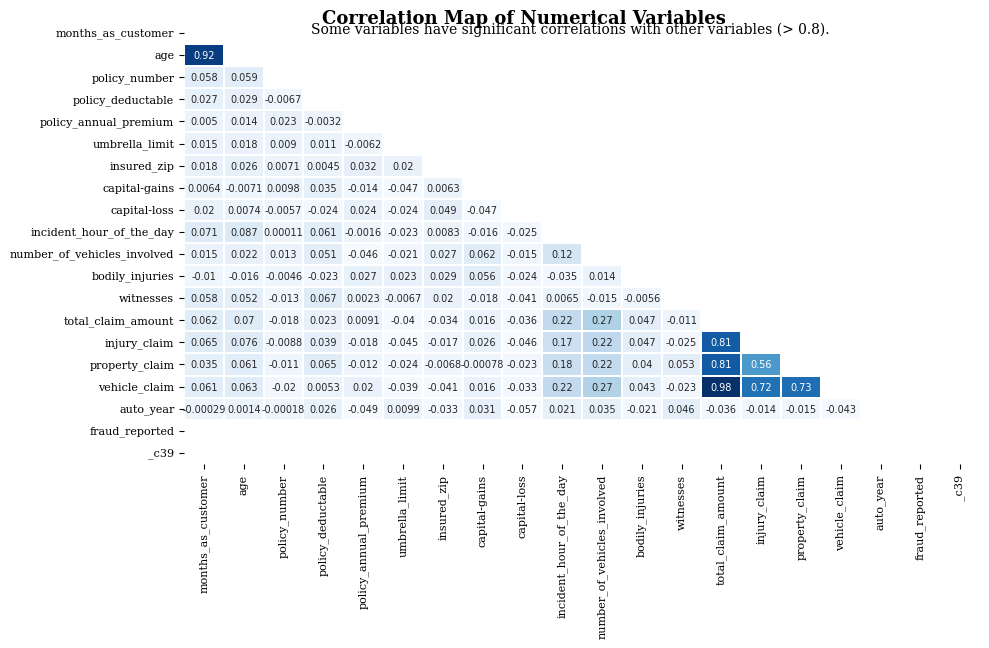

In [ ]:
df.fraud_reported = df.fraud_reported.map(dict(Y = 1 , N = 0))

fig , ax  = plt.subplots(figsize = (10,7))

corr = df[df.select_dtypes(exclude="object").columns].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr , annot=True , mask = mask , cmap = "Blues" , linewidths=.1 , cbar = False , annot_kws={"size":7})
yticks, ylabels = plt.yticks()
xticks, xlabels = plt.xticks()
ax.set_xticklabels(xlabels, size=8, fontfamily='serif')
ax.set_yticklabels(ylabels, size=8, fontfamily='serif')
plt.suptitle('Correlation Map of Numerical Variables', fontweight='heavy', x=0.327, y=0.96, ha='left', fontsize=13, fontfamily='serif')
plt.title('Some variables have significant correlations with other variables (> 0.8).\n', fontsize=10, x=0.16, y=0.92, fontfamily='serif', loc='left')
plt.tight_layout(rect=[0, 0.04, 1, 1.01])

In [ ]:
import copy
corr_multi = corr[corr>=0.8].reset_index()

melted_corr = pd.melt(copy.deepcopy(corr_multi) , id_vars="index" , var_name="correlation").sort_values(by = ["correlation"]).dropna()
melted_corr.columns = ['row_name', 'column_name', 'correlation']

melted_corr = melted_corr[melted_corr['row_name'] != melted_corr['column_name']].drop_duplicates(subset='correlation')

melted_corr

,row_name,column_name,correlation
20,months_as_customer,age,0.922098
293,total_claim_amount,injury_claim,0.805025
313,total_claim_amount,property_claim,0.810686
276,vehicle_claim,total_claim_amount,0.982773



To reduce multicollinerity we can drop either `total_claim_amount` from the data, since `total_claim_amount` = `injury_claim `+ `property_claim` + `vehicle_claim`

or the other three (`injury_claim, property_claim, vehicle_claim`)

# **4. XGBoost Method**

In [ ]:
from sklearn.preprocessing import  StandardScaler
from sklearn.preprocessing import  LabelEncoder

cat_cols = []

for col in df.columns:
    if (df[col].dtype =='object'):
        cat_cols.append(col)

num_cols = []

for col in df.columns:
    if (df[col].dtype =='int'):
        num_cols.append(col)



In [ ]:
sd = StandardScaler()
df[num_cols] = sd.fit_transform(df[num_cols])

In [ ]:
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [ ]:
from xgboost import  XGBClassifier
from sklearn.model_selection import  train_test_split

x = df.iloc[: , 0:-1]
y = df.iloc[: , -2]

x_train , x_test , y_train  , y_test = train_test_split(x , y, test_size = .2 , random_state = 42)


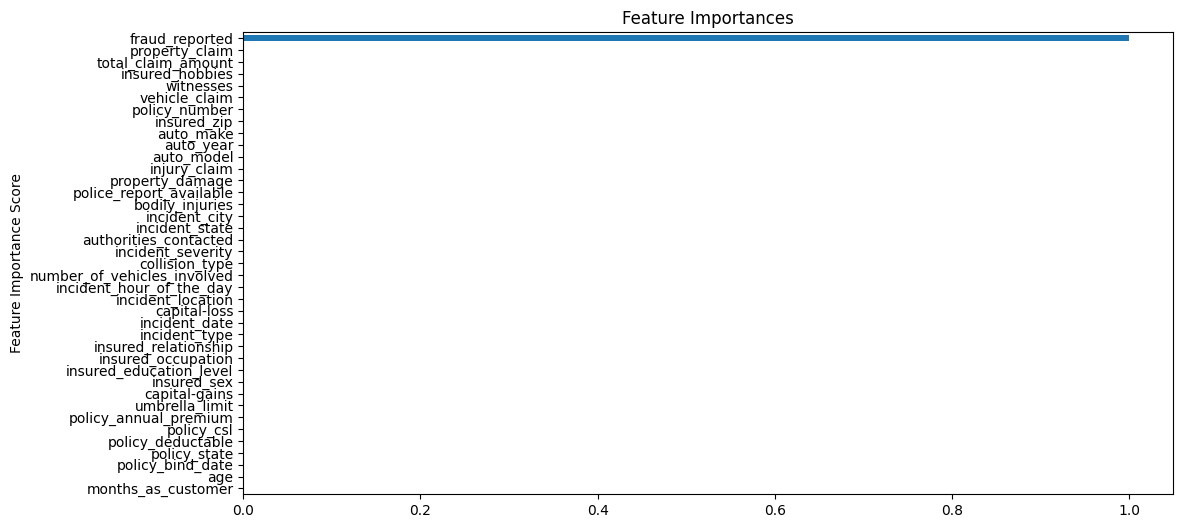

In [ ]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

xgb = XGBClassifier()

xgb.fit(
x_train , y_train
)

fig, ax = plt.subplots(figsize=(12,6))

feat_imp = pd.Series(

    xgb.feature_importances_,
    x_train.columns.to_list()

).sort_values(ascending=True)

feat_imp.plot(kind='barh', title='Feature Importances')

plt.ylabel('Feature Importance Score')
plt.show()

# **4. Random Forest**

/tmp/ipython-input-1065612473.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontname='serif', fontsize=8)
/tmp/ipython-input-1065612473.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(rf_feature_names, fontname='serif', fontsize=8)


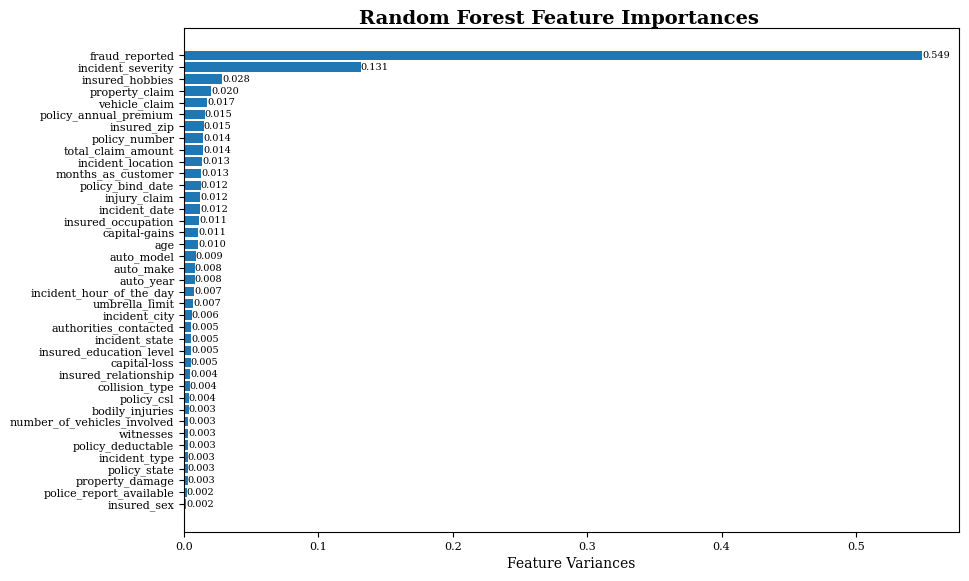

In [ ]:
from sklearn.ensemble import  RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(
x_train, y_train
)

sorted_index = rf.feature_importances_.argsort()
fig, ax = plt.subplots(figsize=(10,6))

fig.suptitle("Random Forest Feature Importances", fontsize=14, fontname='serif', fontweight='bold')
fig.subplots_adjust(top=0.95)

rf_importances = rf.feature_importances_[sorted_index]
rf_feature_names = x_train.columns[sorted_index]

ax.barh(rf_feature_names, rf_importances)

ax.set_xlabel("Feature Variances", fontsize=10, fontname='serif')
ax.set_xticklabels(ax.get_xticklabels(), fontname='serif', fontsize=8)
ax.set_yticklabels(rf_feature_names, fontname='serif', fontsize=8)

# Add labels to the bars
for i in range(len(rf_importances)):
    ax.text(rf_importances[i], i, f"{rf_importances[i]:.3f}", ha='left', va='center', fontsize=7, fontname='serif')


plt.show()